# Modelo de Motivo de Rechazo — Evaluacion Aislada

**Hackathon AI Telecom Challenge 2026 — Desafio 02 (Personalizacion Comercial Inteligente)**

## Objetivo

Medir si un clasificador multiclase sobre `motivo_rechazo` supera a la heuristica que hoy corre en produccion: `motor_reglas_negocio.motivo_rechazo_probable()`.

## Por que importa

La heuristica actual es un `if/else` de 4 ramas que declara su propia confianza como `"heuristica"` y **solo puede emitir 4 de los 6 motivos** del catalogo: nunca predice `ya_tiene_similar` ni `mal_momento`. Esa funcion alimenta `estrategia_rebate()`, que si maneja los 6, y esa estrategia gobierna la cascada Top-3 y el speech de rebate.

Mientras tanto `historial_campanias.csv` trae ~111,632 filas rechazadas **con el motivo real etiquetado**, que hoy no se usan en ningun modelo.

## Alcance

**Este notebook NO modifica el motor.** Entrena, evalua y serializa el artefacto en `data/processed/modelo_motivo_rechazo/`. La integracion (y la preservacion del contrato de retorno de `motivo_rechazo_probable`) queda fuera de este analisis, deliberadamente.

## Protocolo

Identico al de `EDA_logistica_corregida.ipynb` para que los numeros sean comparables: `GroupShuffleSplit` 80/20 por `cliente_id` (test reservado, no se abre) y `GroupKFold(5)` Out-Of-Fold dentro de train.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, accuracy_score, log_loss,
    top_k_accuracy_score, classification_report, confusion_matrix,
)
from sklearn.base import clone

import lightgbm as lgb

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 1000)

RANDOM_STATE = 42
DIR_SALIDA = Path("../data/processed/modelo_motivo_rechazo")
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

## 1. Carga y limpieza

Se replican exactamente las convenciones de limpieza de `EDA_logistica_corregida.ipynb` (lowercase de categoricas, recodificacion de nulos estructurales) para que ambos notebooks trabajen sobre la misma base.

In [2]:
clientes = pd.read_csv("../data/raw/dataset_clientes.csv")
catalogo = pd.read_csv("../data/raw/catalogo_ofertas_entrega.csv")
campanias = pd.read_csv("../data/raw/historial_campanias.csv", parse_dates=["fecha"])

ids = ["cliente_id", "oferta_id", "ofrecimiento_id", "oferta_hogar_id", "plan_actual_id"]
for df in (clientes, catalogo, campanias):
    for col in df.select_dtypes(include=["object", "str"]).columns:
        if col not in ids:
            df[col] = df[col].astype(str).str.strip().str.lower()

# pandas 3 rechaza escribir texto en columnas float64 (p.ej. una columna 100% nula).
# El notebook original asume dtype object; se fuerza antes de recodificar.
for _df, _cols in ((clientes, ["oferta_hogar_id", "tipo_cliente", "canal_mas_usado"]),
                   (catalogo, ["cluster_hogar", "descripcion_bundle"])):
    for _c in _cols:
        _df[_c] = _df[_c].astype(object)

clientes.loc[clientes["oferta_hogar_id"].isna() & (clientes["tiene_hogar"] == False), "oferta_hogar_id"] = "sin_servicio_hogar"
clientes.loc[clientes["tipo_cliente"].isna() & (clientes["tiene_movil"] == False), "tipo_cliente"] = "sin_movil"
clientes.loc[clientes["canal_mas_usado"].isna() & (clientes["n_actividad_canal"] == 0), "canal_mas_usado"] = "sin_actividad"

catalogo.loc[catalogo["cluster_hogar"].isna() & (catalogo["tipo_oferta"] != "plan_hogar"), "cluster_hogar"] = "no_aplica"
catalogo.loc[catalogo["descripcion_bundle"].isna() & (catalogo["tipo_oferta"] != "plan_hogar"), "descripcion_bundle"] = "no_aplica"

analitica = campanias.merge(clientes, on="cliente_id", how="left", suffixes=("_camp", "_cli"))
for col in ["tipo_cliente", "antiguedad_meses", "elegible_mt", "es_movistar_total"]:
    analitica[col] = analitica[f"{col}_cli"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cli"])

catalogo_join = catalogo.rename(columns={"es_movistar_total": "oferta_catalogo_es_mt"})
analitica = analitica.merge(catalogo_join, on="oferta_id", how="left", suffixes=("_camp", "_cat"))
for col in ["nombre_oferta", "tipo_oferta"]:
    analitica[col] = analitica[f"{col}_cat"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cat"])

print(f"Filas de campania: {len(analitica):,}")
print(analitica["resultado"].value_counts())

Filas de campania: 300,112
resultado
rechazada    159204
aceptada      95414
pendiente     45494
Name: count, dtype: int64


## 2. Universo de rechazos

El modelo es **condicional al rechazo**: solo se entrena sobre filas donde `resultado == 'rechazada'`, las unicas con `motivo_rechazo` etiquetado. En produccion se invoca exactamente en ese punto: cuando el asesor registra un rechazo y necesita el speech de rebate.

Filas de rechazo con motivo etiquetado: 159,204
Clientes unicos: 79,005



Distribucion de motivos (%):
motivo_rechazo
precio              34.96
no_necesita         19.98
ya_tiene_similar    15.05
mal_momento         15.03
no_confia           10.04
otro                 4.94
Name: proportion, dtype: float64

Clase mayoritaria: precio (34.96%)  <- piso de accuracy trivial


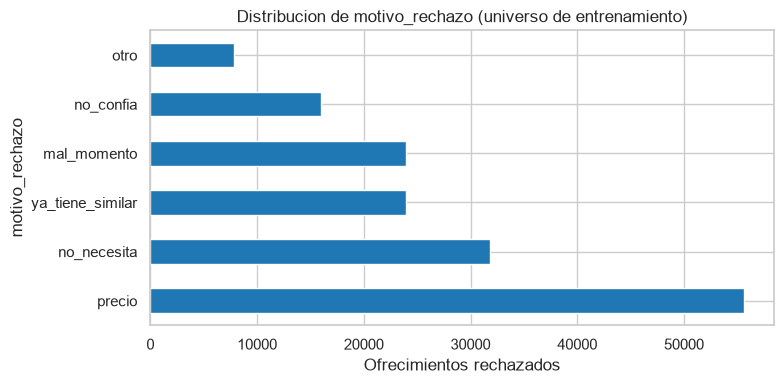

In [3]:
MOTIVOS = ["precio", "no_necesita", "ya_tiene_similar", "mal_momento", "no_confia", "otro"]

rechazos = analitica[analitica["resultado"] == "rechazada"].copy()
rechazos = rechazos[rechazos["motivo_rechazo"].isin(MOTIVOS)].copy()

print(f"Filas de rechazo con motivo etiquetado: {len(rechazos):,}")
print(f"Clientes unicos: {rechazos['cliente_id'].nunique():,}")
print()
dist = rechazos["motivo_rechazo"].value_counts(normalize=True).mul(100).round(2)
print("Distribucion de motivos (%):")
print(dist)
print()
print(f"Clase mayoritaria: {dist.index[0]} ({dist.iloc[0]:.2f}%)  <- piso de accuracy trivial")

fig, ax = plt.subplots(figsize=(8, 4))
rechazos["motivo_rechazo"].value_counts().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Distribucion de motivo_rechazo (universo de entrenamiento)")
ax.set_xlabel("Ofrecimientos rechazados")
plt.tight_layout()
plt.show()

## 3. Feature engineering

Tres bloques:

1. **Perfil y oferta** — las mismas variables del modelo de propension.
2. **Derivadas que codifican la logica de la heuristica** (`precio_vs_facturacion`, `menor_capacidad_datos`, `nivel_riesgo`). Se incluyen a proposito: si el modelo no supera a la heuristica teniendo sus mismos insumos, la heuristica se queda.
3. **Temporales estrictamente pasadas** — `fecha` no se usa hoy en ningun modelo del proyecto. Se calculan con `shift(1)` sobre el orden cronologico por cliente para no filtrar el presente.

In [4]:
rechazos = rechazos.sort_values(["cliente_id", "fecha"]).reset_index(drop=True)

# Bloque 3: temporales estrictamente pasadas (anti-leakage via shift)
grp = rechazos.groupby("cliente_id", sort=False)
rechazos["n_rechazos_previos"] = grp.cumcount()
rechazos["dias_desde_ultimo_rechazo"] = (rechazos["fecha"] - grp["fecha"].shift(1)).dt.days
rechazos["motivo_rechazo_previo"] = grp["motivo_rechazo"].shift(1).fillna("sin_previo")
rechazos["mismo_tipo_oferta_que_previo"] = (
    rechazos["tipo_oferta"] == grp["tipo_oferta"].shift(1)
).fillna(False)
rechazos["mes"] = rechazos["fecha"].dt.month

# Bloque 2: derivadas que replican los insumos de la heuristica
planes = catalogo.set_index("oferta_id")
rechazos["gb_plan_actual"] = rechazos["plan_actual_id"].map(planes["gb_incluidos"])
rechazos["precio_plan_actual"] = rechazos["plan_actual_id"].map(planes["precio_mensual"])

fact = rechazos["monto_facturado_prom"].replace(0, np.nan)
rechazos["precio_vs_facturacion"] = rechazos["precio_mensual"] / fact
rechazos["delta_precio"] = rechazos["precio_mensual"] - rechazos["precio_plan_actual"]
rechazos["delta_gb"] = (
    rechazos["gb_incluidos"].replace(9999, np.nan) - rechazos["gb_plan_actual"].replace(9999, np.nan)
)
rechazos["menor_capacidad_datos"] = (
    (rechazos["gb_incluidos"] < rechazos["gb_plan_actual"])
    & (rechazos["gb_plan_actual"] < 9999)
    & rechazos["gb_incluidos"].notna()
).fillna(False)
rechazos["oferta_ilimitada"] = rechazos["gb_incluidos"] == 9999
rechazos["gb_incluidos_modelo"] = rechazos["gb_incluidos"].replace(9999, np.nan)

def nivel_riesgo_vec(df: pd.DataFrame) -> pd.Series:
    """Port vectorizado de motor_reglas_negocio.nivel_riesgo()."""
    meses = df["meses_moroso"].astype(float)
    dias = df["dias_mora_prom"].astype(float)
    out = pd.Series("bajo", index=df.index)
    out[(meses >= 1) | (dias > 5)] = "medio"
    out[(meses >= 2) | (dias > 10)] = "alto"
    return out

rechazos["nivel_riesgo"] = nivel_riesgo_vec(rechazos)

NUMERICAS = [
    "antiguedad_meses", "monto_facturado_prom", "monto_facturado_prom_6m",
    "consumo_datos_gb_prom", "consumo_voz_min_prom", "consumo_sms_prom",
    "uso_app_movistar_prom", "dias_mora_prom", "precio_mensual", "ahorro_pct",
    "gb_incluidos_modelo", "precio_vs_facturacion", "delta_precio", "delta_gb",
    "n_rechazos_previos", "dias_desde_ultimo_rechazo",
]
CATEGORICAS = [
    "tipo_cliente", "tiene_movil", "tiene_hogar", "tiene_internet_hogar",
    "es_movistar_total", "elegible_mt", "plan_actual_id", "oferta_hogar_id",
    "edad_rango", "ubicacion_departamento", "es_usuario_app", "meses_moroso",
    "n_reclamos", "canal_mas_usado", "canal", "tipo_oferta", "oferta_es_mt",
    "segmento_objetivo", "cluster_hogar", "oferta_ilimitada",
    "menor_capacidad_datos", "nivel_riesgo", "motivo_rechazo_previo",
    "mismo_tipo_oferta_que_previo", "mes",
]

X = rechazos[NUMERICAS + CATEGORICAS].copy()
for c in CATEGORICAS:
    X[c] = X[c].astype(str)

y = rechazos["motivo_rechazo"].astype(str)
grupos = rechazos["cliente_id"]

print(f"X: {X.shape}   clases: {sorted(y.unique())}")

X: (159204, 41)   clases: ['mal_momento', 'no_confia', 'no_necesita', 'otro', 'precio', 'ya_tiene_similar']


## 4. Split agrupado por cliente

`GroupShuffleSplit` reserva 20% de **clientes** (no de filas) para test. Ese test **no se abre en este notebook**: toda la comparacion es Out-Of-Fold sobre train, igual que en el notebook de logistica.

In [5]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
idx_train, idx_test = next(splitter.split(X, y, groups=grupos))

X_train = X.iloc[idx_train].copy()
y_train = y.iloc[idx_train].copy()
g_train = grupos.iloc[idx_train].copy()
X_test = X.iloc[idx_test].copy()
y_test = y.iloc[idx_test].copy()
raw_train = rechazos.iloc[idx_train].copy()

group_kfold = GroupKFold(n_splits=5)
CLASES = sorted(y_train.unique())

print(f"Train: {len(X_train):,} filas / {g_train.nunique():,} clientes")
print(f"Test reservado (NO se abre): {len(X_test):,} filas")

Train: 127,430 filas / 63,204 clientes
Test reservado (NO se abre): 31,774 filas


## 5. Baselines — incluida la heuristica en produccion

Cuatro pisos contra los que medir. El unico que realmente decide es **B2**, que es el codigo que hoy corre en el motor: si el modelo no lo supera, no hay caso.

| Baseline | Que es |
|---|---|
| B0 | Clase mayoritaria |
| B1 | Muestreo segun la prior de clases |
| **B2** | **Port fiel de `motivo_rechazo_probable()` (heuristica en produccion)** |
| B3 | Moda por segmento `(tipo_oferta, elegible_mt, canal)`, calculada solo en los folds de ajuste |

In [6]:
def heuristica_motivo_rechazo(df: pd.DataFrame) -> pd.Series:
    """Port fiel de motor_reglas_negocio.motivo_rechazo_probable() (linea 288).

    Cadena original de 4 ramas, en el mismo orden de precedencia:
        1. precio       si facturacion > 0 y precio > facturacion * 1.15
        2. no_confia    si n_reclamos >= 3
        3. no_necesita  si warning MENOR_CAPACIDAD_DATOS
        4. otro         en cualquier otro caso

    Nunca puede emitir 'ya_tiene_similar' ni 'mal_momento'.
    """
    precio = df["precio_mensual"].astype(float)
    facturacion = df["monto_facturado_prom"].astype(float)
    reclamos = df["n_reclamos"].astype(float)
    menor_capacidad = df["menor_capacidad_datos"].astype(bool)

    out = pd.Series("otro", index=df.index, dtype=object)
    cond_precio = (facturacion > 0) & (precio > facturacion * 1.15)
    cond_confia = ~cond_precio & (reclamos >= 3)
    cond_necesita = ~cond_precio & ~cond_confia & menor_capacidad

    out[cond_necesita] = "no_necesita"
    out[cond_confia] = "no_confia"
    out[cond_precio] = "precio"
    return out

heur_train = heuristica_motivo_rechazo(raw_train)
heur_train.index = y_train.index

print("Motivos que la heuristica PUEDE emitir:", sorted(heur_train.unique()))
print("Motivos presentes en la realidad:      ", CLASES)
faltantes = sorted(set(CLASES) - set(heur_train.unique()))
print()
print(f"Clases estructuralmente inalcanzables para la heuristica: {faltantes}")
cobertura_perdida = float(y_train.isin(faltantes).mean())
print(f"Porcion del universo real que la heuristica NUNCA puede acertar: {cobertura_perdida:.2%}")

Motivos que la heuristica PUEDE emitir: ['no_confia', 'no_necesita', 'otro', 'precio']
Motivos presentes en la realidad:       ['mal_momento', 'no_confia', 'no_necesita', 'otro', 'precio', 'ya_tiene_similar']

Clases estructuralmente inalcanzables para la heuristica: ['mal_momento', 'ya_tiene_similar']
Porcion del universo real que la heuristica NUNCA puede acertar: 30.06%


In [7]:
rng = np.random.default_rng(RANDOM_STATE)

pred_b0 = pd.Series(y_train.value_counts().index[0], index=y_train.index)
prior = y_train.value_counts(normalize=True)
pred_b1 = pd.Series(rng.choice(prior.index, size=len(y_train), p=prior.values), index=y_train.index)
pred_b2 = heur_train

# B3: moda por segmento, calculada solo en folds de ajuste (sin fuga)
SEG = ["tipo_oferta", "elegible_mt", "canal"]
pred_b3 = pd.Series(index=y_train.index, dtype=object)
for idx_fit, idx_val in group_kfold.split(X_train, y_train, groups=g_train):
    fit_df = raw_train.iloc[idx_fit]
    moda = fit_df.groupby(SEG)["motivo_rechazo"].agg(lambda s: s.value_counts().index[0])
    global_moda = fit_df["motivo_rechazo"].value_counts().index[0]
    claves = pd.MultiIndex.from_frame(raw_train.iloc[idx_val][SEG].astype(str))
    moda.index = moda.index.set_levels([lvl.astype(str) for lvl in moda.index.levels])
    pred_b3.iloc[idx_val] = moda.reindex(claves).fillna(global_moda).to_numpy()

BASELINES = {
    "B0_clase_mayoritaria": pred_b0,
    "B1_prior_aleatoria": pred_b1,
    "B2_heuristica_produccion": pred_b2,
    "B3_moda_por_segmento": pred_b3,
}
print("Baselines construidos:", list(BASELINES))

Baselines construidos: ['B0_clase_mayoritaria', 'B1_prior_aleatoria', 'B2_heuristica_produccion', 'B3_moda_por_segmento']


## 6. Modelos candidatos

Mismo preprocesamiento para ambos, para que la comparacion sea sobre el modelo y no sobre el pipeline. `RobustScaler` porque el notebook de logistica ya demostro que es el mejor escalador para estas distribuciones sesgadas.

Nota de compatibilidad: en scikit-learn 1.9 `LogisticRegression` es multinomial por defecto con `lbfgs`; el parametro `multi_class` fue removido.

In [8]:
preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", RobustScaler()),
    ]), NUMERICAS),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="faltante")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ]), CATEGORICAS),
])

MODELOS = {
    "M1_logistica_multinomial": Pipeline([
        ("preproc", clone(preproc)),
        ("clf", LogisticRegression(C=0.5, max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "M2_lightgbm_multiclase": Pipeline([
        ("preproc", clone(preproc)),
        ("clf", lgb.LGBMClassifier(
            objective="multiclass", num_class=len(CLASES), n_estimators=400,
            learning_rate=0.05, num_leaves=63, min_child_samples=40,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )),
    ]),
}
print("Modelos candidatos:", list(MODELOS))

Modelos candidatos: ['M1_logistica_multinomial', 'M2_lightgbm_multiclase']


## 7. Evaluacion Out-Of-Fold

Metricas elegidas y por que:

- **macro-F1** — metrica principal. Trata las 6 clases por igual; es la unica que castiga ignorar las minoritarias, que es exactamente el fallo de la heuristica.
- **balanced accuracy** — accuracy corregida por prior.
- **accuracy** — se reporta solo para contrastar contra el piso trivial de B0.
- **top-2 accuracy** — operacionalmente relevante: con dos motivos el asesor tiene dos guiones listos.
- **log-loss** — solo para modelos; mide si la confianza esta calibrada, algo que la heuristica no puede ofrecer (devuelve `"heuristica"` como confianza fija).
- **clases_emitidas** — cuantas de las 6 clases el predictor llega a producir.

In [9]:
def evaluar_predicciones(nombre, y_true, y_pred, proba=None, clases=None):
    fila = {
        "predictor": nombre,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "clases_emitidas": int(pd.Series(y_pred).nunique()),
    }
    if proba is not None and clases is not None:
        fila["log_loss"] = log_loss(y_true, proba, labels=clases)
        fila["top2_accuracy"] = top_k_accuracy_score(y_true, proba, k=2, labels=clases)
    else:
        fila["log_loss"] = np.nan
        fila["top2_accuracy"] = np.nan
    return fila

def oof_modelo(pipeline, X_tr, y_tr, g_tr, clases):
    """Probabilidades OOF alineadas posicionalmente a X_tr."""
    proba = np.zeros((len(X_tr), len(clases)))
    for idx_fit, idx_val in group_kfold.split(X_tr, y_tr, groups=g_tr):
        cand = clone(pipeline)
        cand.fit(X_tr.iloc[idx_fit], y_tr.iloc[idx_fit])
        p = cand.predict_proba(X_tr.iloc[idx_val])
        # Realinear columnas por si un fold no vio alguna clase
        col = {c: i for i, c in enumerate(cand.named_steps["clf"].classes_)}
        for j, c in enumerate(clases):
            if c in col:
                proba[idx_val, j] = p[:, col[c]]
    return proba

resultados = [evaluar_predicciones(n, y_train, p) for n, p in BASELINES.items()]

probas_oof = {}
for nombre, pipe in MODELOS.items():
    print(f"Entrenando {nombre} ...")
    proba = oof_modelo(pipe, X_train, y_train, g_train, CLASES)
    probas_oof[nombre] = proba
    pred = pd.Series([CLASES[i] for i in proba.argmax(axis=1)], index=y_train.index)
    resultados.append(evaluar_predicciones(nombre, y_train, pred, proba, CLASES))

tabla = pd.DataFrame(resultados).set_index("predictor")
tabla = tabla[["macro_f1", "balanced_accuracy", "accuracy", "top2_accuracy",
               "weighted_f1", "log_loss", "clases_emitidas"]]
print()
print(tabla.round(4).to_string())

Entrenando M1_logistica_multinomial ...


Entrenando M2_lightgbm_multiclase ...



                          macro_f1  balanced_accuracy  accuracy  top2_accuracy  weighted_f1  log_loss  clases_emitidas
predictor                                                                                                             
B0_clase_mayoritaria        0.0863             0.1667    0.3494            NaN       0.1810       NaN                1
B1_prior_aleatoria          0.1654             0.1654    0.2185            NaN       0.2186       NaN                6
B2_heuristica_produccion    0.1232             0.1678    0.2037            NaN       0.1813       NaN                4
B3_moda_por_segmento        0.0863             0.1667    0.3494            NaN       0.1810       NaN                1
M1_logistica_multinomial    0.0864             0.1666    0.3493         0.5496       0.1810    1.6402                2
M2_lightgbm_multiclase      0.0949             0.1670    0.3451         0.5372       0.1897    1.6578                6


Mejora en macro-F1 sobre la heuristica en produccion:
predictor
B1_prior_aleatoria          0.0422
B2_heuristica_produccion    0.0000
M2_lightgbm_multiclase     -0.0283
M1_logistica_multinomial   -0.0368
B0_clase_mayoritaria       -0.0369
B3_moda_por_segmento       -0.0369

Lectura: si el mejor modelo no supera a B2 de forma clara,
la recomendacion honesta es dejar la heuristica y documentar por que.


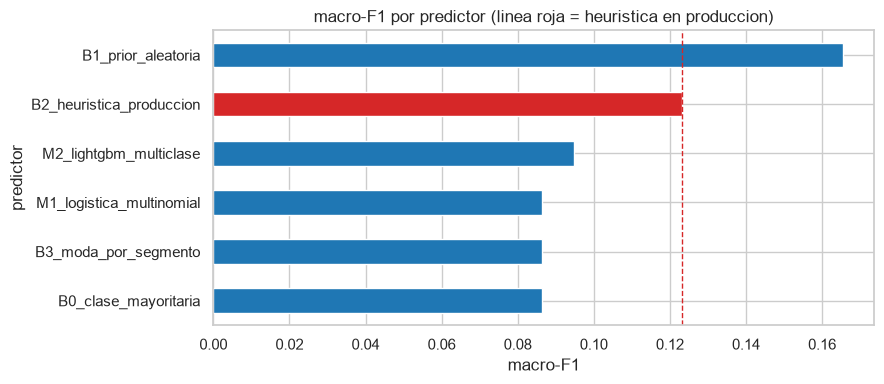

In [10]:
base = tabla.loc["B2_heuristica_produccion", "macro_f1"]
delta = (tabla["macro_f1"] - base).rename("delta_macro_f1_vs_heuristica")
print("Mejora en macro-F1 sobre la heuristica en produccion:")
print(delta.round(4).sort_values(ascending=False).to_string())
print()
print("Lectura: si el mejor modelo no supera a B2 de forma clara,")
print("la recomendacion honesta es dejar la heuristica y documentar por que.")

fig, ax = plt.subplots(figsize=(9, 4))
orden = tabla["macro_f1"].sort_values()
colores = ["#d62728" if "B2" in i else "#1f77b4" for i in orden.index]
orden.plot(kind="barh", ax=ax, color=colores)
ax.axvline(base, ls="--", c="#d62728", lw=1)
ax.set_title("macro-F1 por predictor (linea roja = heuristica en produccion)")
ax.set_xlabel("macro-F1")
plt.tight_layout()
plt.show()

## 8. Metrica de negocio: acierto a nivel de ACCION

El motivo predicho no es el entregable: lo es la **accion** que dispara via `estrategia_rebate()`. Dos motivos distintos pueden mapear a la misma accion, asi que la accuracy a nivel de motivo subestima el valor operativo.

Solo dos motivos sacan al asesor del camino "ofrecer alternativa":

- `mal_momento` -> `programar_seguimiento` (no insistir)
- `no_confia` -> `derivar_canal_asistido`

Y `mal_momento` es justamente una de las clases que la heuristica **no puede emitir jamas**: cada vez que el cliente dijo "mal momento", el motor insiste igual.

In [11]:
# Port de motor_reglas_negocio.estrategia_rebate()
ESTRATEGIA = {
    "precio":           ("ofrecer_alternativa", "menor_precio"),
    "no_necesita":      ("ofrecer_alternativa", "otra_categoria"),
    "ya_tiene_similar": ("ofrecer_alternativa", "producto_complementario"),
    "mal_momento":      ("programar_seguimiento", "no_insistir"),
    "no_confia":        ("derivar_canal_asistido", "resolver_dudas_antes_de_ofrecer"),
    "otro":             ("ofrecer_alternativa", "siguiente_mejor_score"),
}
a_accion = {k: v[0] for k, v in ESTRATEGIA.items()}

todas = dict(BASELINES)
for nombre, proba in probas_oof.items():
    todas[nombre] = pd.Series([CLASES[i] for i in proba.argmax(axis=1)], index=y_train.index)

y_accion = y_train.map(a_accion)
filas_accion = []
for nombre, pred in todas.items():
    pa = pd.Series(pred, index=y_train.index).map(a_accion)
    filas_accion.append({
        "predictor": nombre,
        "accuracy_accion": accuracy_score(y_accion, pa),
        "macro_f1_accion": f1_score(y_accion, pa, average="macro", zero_division=0),
        "f1_programar_seguimiento": f1_score(
            y_accion == "programar_seguimiento", pa == "programar_seguimiento",
            zero_division=0),
        "f1_derivar_canal": f1_score(
            y_accion == "derivar_canal_asistido", pa == "derivar_canal_asistido",
            zero_division=0),
    })

tabla_accion = pd.DataFrame(filas_accion).set_index("predictor")
print("Rendimiento a nivel de ACCION comercial (lo que el asesor realmente hace):")
print(tabla_accion.round(4).to_string())
print()
print(f"Casos reales de 'no insistir' en el universo: {(y_accion == 'programar_seguimiento').mean():.2%}")
print("La heuristica los trata todos como 'ofrecer alternativa'.")

Rendimiento a nivel de ACCION comercial (lo que el asesor realmente hace):
                          accuracy_accion  macro_f1_accion  f1_programar_seguimiento  f1_derivar_canal
predictor                                                                                             
B0_clase_mayoritaria               0.7492           0.2855                    0.0000            0.0000
B1_prior_aleatoria                 0.5938           0.3322                    0.1505            0.0966
B2_heuristica_produccion           0.7199           0.2996                    0.0000            0.0592
B3_moda_por_segmento               0.7492           0.2855                    0.0000            0.0000
M1_logistica_multinomial           0.7492           0.2855                    0.0000            0.0000
M2_lightgbm_multiclase             0.7472           0.2888                    0.0100            0.0011

Casos reales de 'no insistir' en el universo: 15.04%
La heuristica los trata todos como 'ofrecer alt

## 9. Matriz de confusion y desempeno por clase

Mejor predictor por macro-F1: B1_prior_aleatoria



                  precision    recall  f1-score   support

     mal_momento       0.15      0.15      0.15     19163
       no_confia       0.10      0.10      0.10     12796
     no_necesita       0.20      0.20      0.20     25532
            otro       0.05      0.05      0.05      6271
          precio       0.35      0.35      0.35     44526
ya_tiene_similar       0.15      0.15      0.15     19142

        accuracy                           0.22    127430
       macro avg       0.17      0.17      0.17    127430
    weighted avg       0.22      0.22      0.22    127430



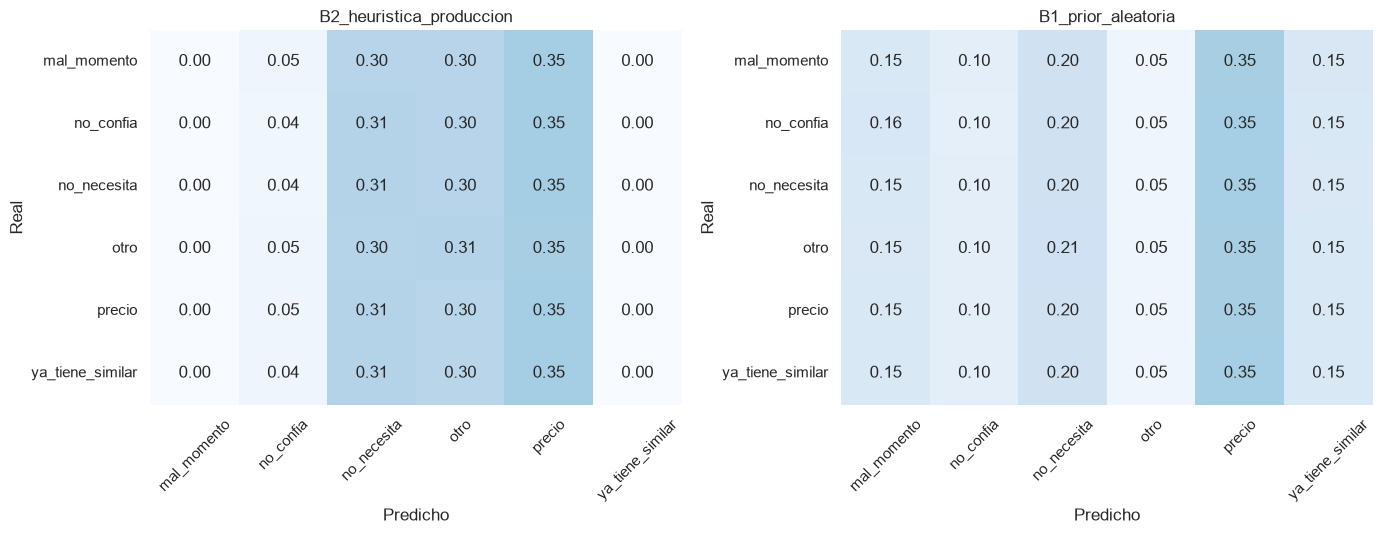

Las columnas vacias en el panel izquierdo son las clases que la heuristica no puede emitir.


In [12]:
mejor = tabla["macro_f1"].idxmax()
print(f"Mejor predictor por macro-F1: {mejor}")
print()
print(classification_report(y_train, todas[mejor], labels=CLASES, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, nombre in zip(axes, ["B2_heuristica_produccion", mejor]):
    cm = confusion_matrix(y_train, todas[nombre], labels=CLASES, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=CLASES, yticklabels=CLASES, ax=ax, vmin=0, vmax=1)
    ax.set_title(nombre)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print("Las columnas vacias en el panel izquierdo son las clases que la heuristica no puede emitir.")

## 10. Consolidacion y serializacion

Se entrena el mejor candidato sobre **todo** el train y se serializa junto al reporte. El test sigue reservado.

In [13]:
import joblib

reporte = {
    "universo": {
        "filas_rechazo": int(len(rechazos)),
        "clientes": int(rechazos["cliente_id"].nunique()),
        "clases": CLASES,
        "distribucion": rechazos["motivo_rechazo"].value_counts(normalize=True).round(4).to_dict(),
    },
    "protocolo": {
        "split": "GroupShuffleSplit 80/20 por cliente_id",
        "cv": "GroupKFold(5) OOF dentro de train",
        "test_reservado_abierto": False,
        "metrica_principal": "macro_f1",
    },
    "heuristica_produccion": {
        "fuente": "backend/Motor/motor_reglas_negocio.py::motivo_rechazo_probable",
        "clases_alcanzables": sorted(heur_train.unique()),
        "clases_inalcanzables": faltantes,
        "porcion_universo_inalcanzable": cobertura_perdida,
    },
    "metricas_motivo": tabla.round(6).reset_index().to_dict(orient="records"),
    "metricas_accion": tabla_accion.round(6).reset_index().to_dict(orient="records"),
    "mejor_predictor": mejor,
}

with open(DIR_SALIDA / "reporte_motivo_rechazo.json", "w", encoding="utf-8") as fh:
    json.dump(reporte, fh, ensure_ascii=False, indent=2)
tabla.to_csv(DIR_SALIDA / "comparacion_predictores.csv")
tabla_accion.to_csv(DIR_SALIDA / "comparacion_acciones.csv")

if mejor in MODELOS:
    final = clone(MODELOS[mejor])
    final.fit(X_train, y_train)
    joblib.dump(
        {"pipeline": final, "clases": CLASES,
         "features_num": NUMERICAS, "features_cat": CATEGORICAS},
        DIR_SALIDA / "modelo_motivo_rechazo.joblib",
    )
    print(f"Artefacto serializado: {DIR_SALIDA / 'modelo_motivo_rechazo.joblib'}")
else:
    print("Gano un baseline: no hay modelo que serializar. Ese es el resultado.")

print(f"Reporte: {DIR_SALIDA / 'reporte_motivo_rechazo.json'}")

Gano un baseline: no hay modelo que serializar. Ese es el resultado.
Reporte: ..\data\processed\modelo_motivo_rechazo\reporte_motivo_rechazo.json


## 11. Lectura de resultados

Completar tras la ejecucion:

| Pregunta | Respuesta |
|---|---|
| macro-F1 heuristica (B2) | |
| macro-F1 mejor modelo | |
| Delta | |
| Accuracy a nivel de accion: B2 vs modelo | |
| % del universo que B2 no puede acertar jamas | |

**Criterio de decision propuesto.** El modelo reemplaza a la heuristica solo si mejora macro-F1 **y** accuracy a nivel de accion. Si solo mejora accuracy global, probablemente esta explotando la clase mayoritaria y no aporta nada al speech de rebate.

### Si el modelo gana

La integracion posterior — **fuera de este notebook** — deberia preservar el contrato de retorno de `motivo_rechazo_probable()`, es decir `{"motivo", "explicacion", "confianza"}`, sustituyendo `"confianza": "heuristica"` por la probabilidad real de la clase predicha, para que la capa de speech pueda modular el tono segun certeza.

### Si el modelo pierde

Es un hallazgo publicable en el pitch, no un fracaso: significaria que `motivo_rechazo` es en buena medida ruido en el dataset sintetico y que la heuristica esta razonablemente ajustada al problema. Documentarlo cierra la pregunta antes de que la haga el jurado.